# fetch black holes


parameters

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
fetch_black_holes.py — Fetch papers about black holes from OpenAlex,
organised into narrative chapters covering precursor observations,
theoretical development, and confirmatory evidence.

Output:
  black_holes.db          — SQLite with all papers + chapter assignments
  black_holes_raw.json    — Full structured dump ready for curation

Usage:
  python fetch_black_holes.py --email tom.hirsch3000@gmail.com
  python fetch_black_holes.py --email tom.hirsch3000@gmail.com --dry-run
"""


In [2]:
# Cell 1 — config (replaces argparse)
EMAIL = "tom.hirsch3000@gmail.com"
DB = "black_holes.db"
JSON_OUT = "black_holes_raw.json"

In [3]:

import argparse
import io
import json
import sqlite3
import sys
import time
import urllib.parse
import urllib.request
import urllib.error
from typing import Dict, Any, Optional, List

if sys.stdout.encoding and sys.stdout.encoding.lower() != "utf-8":
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding="utf-8", errors="replace")
if sys.stderr.encoding and sys.stderr.encoding.lower() != "utf-8":
    sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding="utf-8", errors="replace")

OPENALEX_BASE = "https://api.openalex.org"
WORKS_URL = f"{OPENALEX_BASE}/works"

OPENALEX_SELECT_FIELDS = [
    "id", "title", "abstract_inverted_index", "cited_by_count",
    "publication_year", "publication_date", "type", "language",
    "doi", "ids", "authorships", "primary_location",
    "concepts", "open_access",
]

# ---------------------------------------------------------------------------
# Narrative chapter definitions
# ---------------------------------------------------------------------------
# Each chapter has:
#   id           — machine-readable slug
#   title        — display title
#   era          — human date range for context
#   role         — "precursor" | "theory" | "evidence"
#   narrative    — placeholder paragraph (fill in by hand / LLM in notebook)
#   queries      — list of OpenAlex search strings to run
#   year_range   — optional (from_year, to_year) tuple to narrow results
#   per_query    — max papers to fetch per search query
#
# Strategy: multiple targeted searches per chapter, then deduplicate.
# OpenAlex `search` hits title + abstract; we also layer in concept filters
# where a concept ID is known.
# ---------------------------------------------------------------------------
CHAPTERS = [
    {
        "id": "precursor_stellar_theory",
        "title": "The Mass Limit Problem: Stars That Cannot Stop Collapsing",
        "era": "1920s – 1950s",
        "role": "precursor",
        "narrative": "",
        "queries": [
            "Chandrasekhar limit white dwarf mass",
            "gravitational collapse stellar evolution",
            "neutron star Tolman Oppenheimer Volkoff",
            "degenerate matter stellar pressure",
            "Oppenheimer Snyder gravitational collapse",
        ],
        "year_range": (1920, 1960),
        "per_query": 30,
    },
    {
        "id": "precursor_redshift",
        "title": "Extreme Redshifts: Light Struggling to Escape",
        "era": "1910s – 1960s",
        "role": "precursor",
        "narrative": "",
        "queries": [
            "gravitational redshift prediction general relativity",
            "pound rebka gravitational redshift experiment",
            "spectral lines gravitational field",
            "redshift compact massive object",
        ],
        "year_range": (1910, 1970),
        "per_query": 30,
    },
    {
        "id": "precursor_quasars",
        "title": "Quasars: Impossibly Bright Objects at the Edge of the Universe",
        "era": "1960s – 1980s",
        "role": "precursor",
        "narrative": "",
        "queries": [
            "quasar quasi-stellar object discovery",
            "quasar redshift energy source",
            "3C 273 quasar spectrum",
            "active galactic nucleus energy mechanism",
            "supermassive black hole quasar power",
        ],
        "year_range": (1960, 1990),
        "per_query": 40,
    },
    {
        "id": "precursor_xray_sky",
        "title": "The X-ray Sky: Sources Too Bright to Ignore",
        "era": "1960s – 1975",
        "role": "precursor",
        "narrative": "",
        "queries": [
            "X-ray astronomy Uhuru satellite discovery",
            "X-ray source binary stellar",
            "cosmic X-ray background compact object",
            "Giacconi X-ray telescope observation",
        ],
        "year_range": (1960, 1978),
        "per_query": 30,
    },
    {
        "id": "theory_foundation",
        "title": "The Mathematics of No Return: Schwarzschild to Penrose",
        "era": "1916 – 1975",
        "role": "theory",
        "narrative": "",
        "queries": [
            "Schwarzschild solution general relativity spherical symmetry",
            "event horizon Kerr black hole solution",
            "singularity theorem Penrose Hawking",
            "black hole thermodynamics Bekenstein",
            "black hole area theorem",
            "Wheeler black hole name",
        ],
        "year_range": (1916, 1980),
        "per_query": 30,
    },
    {
        "id": "theory_hawking",
        "title": "Hawking Radiation: Black Holes Are Not Perfectly Black",
        "era": "1974 – 1990s",
        "role": "theory",
        "narrative": "",
        "queries": [
            "Hawking radiation black hole evaporation",
            "black hole information paradox",
            "quantum effects black hole horizon",
            "particle creation black hole",
        ],
        "year_range": (1970, 2000),
        "per_query": 40,
    },
    {
        "id": "evidence_cygnus_x1",
        "title": "Cygnus X-1: The First Black Hole Candidate",
        "era": "1972 – 1990",
        "role": "evidence",
        "narrative": "",
        "queries": [
            "Cygnus X-1 black hole candidate",
            "X-ray binary compact object mass",
            "black hole X-ray binary accretion disk",
            "HDE 226868 companion star",
        ],
        "year_range": (1970, 1995),
        "per_query": 40,
    },
    {
        "id": "evidence_sgr_a",
        "title": "Sagittarius A*: Watching Stars Orbit the Dark Centre",
        "era": "1990s – 2022",
        "role": "evidence",
        "narrative": "",
        "queries": [
            "Sgr A* galactic center black hole",
            "stellar orbits galactic center S2",
            "Ghez Genzel galactic center stellar motion",
            "supermassive black hole Milky Way",
            "infrared observations galactic center",
        ],
        "year_range": (1990, 2023),
        "per_query": 50,
    },
    {
        "id": "evidence_agn_accretion",
        "title": "Active Galaxies: Accretion Disks Across the Universe",
        "era": "1980s – 2010s",
        "role": "evidence",
        "narrative": "",
        "queries": [
            "active galactic nucleus accretion disk black hole",
            "broad emission line region AGN",
            "reverberation mapping black hole mass",
            "M87 jet black hole",
            "NGC 4258 water maser black hole mass",
        ],
        "year_range": (1980, 2020),
        "per_query": 40,
    },
    {
        "id": "evidence_gravitational_waves",
        "title": "LIGO: Hearing Two Black Holes Merge",
        "era": "2015 – present",
        "role": "evidence",
        "narrative": "",
        "queries": [
            "GW150914 gravitational wave black hole merger",
            "LIGO gravitational wave detection",
            "binary black hole merger gravitational wave",
            "LISA gravitational wave space",
        ],
        "year_range": (2015, 2026),
        "per_query": 50,
    },
    {
        "id": "evidence_eht",
        "title": "The Event Horizon Telescope: A Shadow Photographed",
        "era": "2017 – present",
        "role": "evidence",
        "narrative": "",
        "queries": [
            "Event Horizon Telescope M87 black hole image",
            "black hole shadow photon ring",
            "Sagittarius A* Event Horizon Telescope image",
            "very long baseline interferometry black hole",
        ],
        "year_range": (2017, 2026),
        "per_query": 50,
    },
]

# ---------------------------------------------------------------------------
# HTTP helpers (matches import_openalex.py style)
# ---------------------------------------------------------------------------
def safe_get_json(url: str, params: Dict[str, Any],
                  max_retries: int = 6, base_sleep: float = 0.8) -> Dict[str, Any]:
    qs = urllib.parse.urlencode(params, doseq=True, safe=":,")
    full = f"{url}?{qs}" if qs else url
    for attempt in range(1, max_retries + 1):
        try:
            with urllib.request.urlopen(full, timeout=60) as resp:
                return json.loads(resp.read().decode("utf-8"))
        except urllib.error.HTTPError as e:
            body = ""
            try:
                body = e.read().decode("utf-8", errors="ignore")
            except Exception:
                pass
            if e.code in (429, 500, 502, 503) and attempt < max_retries:
                sleep_s = base_sleep * attempt
                print(f"  [warn] HTTP {e.code} → retry in {sleep_s:.1f}s", flush=True)
                time.sleep(sleep_s)
                continue
            raise RuntimeError(f"HTTP {e.code} on {full}: {body}") from e
        except urllib.error.URLError as e:
            if attempt < max_retries:
                sleep_s = base_sleep * attempt
                print(f"  [warn] URL error '{e}' → retry in {sleep_s:.1f}s", flush=True)
                time.sleep(sleep_s)
                continue
            raise
    return {}


def reconstruct_abstract(inv_idx: Optional[Dict]) -> str:
    if not inv_idx:
        return ""
    pos2tok = {}
    for tok, positions in inv_idx.items():
        for p in positions:
            pos2tok[p] = tok
    if not pos2tok:
        return ""
    max_pos = max(pos2tok.keys())
    return " ".join(pos2tok.get(i, "") for i in range(max_pos + 1)).strip()


# ---------------------------------------------------------------------------
# DB
# ---------------------------------------------------------------------------
SCHEMA_SQL = """
CREATE TABLE IF NOT EXISTS papers (
    paper_id            TEXT PRIMARY KEY,
    title               TEXT,
    abstract            TEXT,
    cited_by_count      INTEGER,
    year                INTEGER,
    publication_date    TEXT,
    doi                 TEXT,
    arxiv_id            TEXT,
    journal_name        TEXT,
    first_author        TEXT,
    all_authors         TEXT,
    institutions        TEXT,
    primary_concept     TEXT,
    concepts_json       TEXT,
    landing_page_url    TEXT,
    is_oa               INTEGER,
    oa_url              TEXT,
    work_type           TEXT,
    language            TEXT
);

CREATE TABLE IF NOT EXISTS paper_chapters (
    paper_id    TEXT NOT NULL,
    chapter_id  TEXT NOT NULL,
    query_used  TEXT,
    PRIMARY KEY (paper_id, chapter_id),
    FOREIGN KEY (paper_id) REFERENCES papers(paper_id)
);
"""


def open_db(path: str) -> sqlite3.Connection:
    conn = sqlite3.connect(path)
    conn.row_factory = sqlite3.Row
    conn.executescript(SCHEMA_SQL)
    conn.commit()
    return conn


def upsert_paper(conn: sqlite3.Connection, work: Dict[str, Any]):
    pid_full = work.get("id", "")
    if not pid_full:
        return None
    pid = pid_full.split("/")[-1]

    abstract = reconstruct_abstract(work.get("abstract_inverted_index"))

    ids = work.get("ids") or {}
    arxiv_url = ids.get("arxiv")
    arxiv_id = arxiv_url.split("/")[-1] if arxiv_url else None

    primary_loc = work.get("primary_location") or {}
    source = primary_loc.get("source") or {}
    journal_name = source.get("display_name")
    landing_url = primary_loc.get("landing_page_url")

    oa = work.get("open_access") or {}
    is_oa = 1 if oa.get("is_oa") else 0
    oa_url = oa.get("oa_url")

    authorships = work.get("authorships") or []
    authors, insts = [], []
    for a in authorships:
        name = (a.get("author") or {}).get("display_name") or a.get("raw_author_name")
        if name:
            authors.append(name)
        for inst in a.get("institutions") or []:
            nm = inst.get("display_name")
            if nm:
                insts.append(nm)

    seen = set()
    authors_u = [x for x in authors if not (x in seen or seen.add(x))]
    seen = set()
    insts_u = [x for x in insts if not (x in seen or seen.add(x))]

    concepts = work.get("concepts") or []
    primary_concept = None
    if concepts:
        best = max(concepts, key=lambda c: c.get("score", 0))
        primary_concept = best.get("display_name")

    conn.execute(
        """
        INSERT OR IGNORE INTO papers (
            paper_id, title, abstract, cited_by_count, year, publication_date,
            doi, arxiv_id, journal_name, first_author, all_authors, institutions,
            primary_concept, concepts_json, landing_page_url, is_oa, oa_url,
            work_type, language
        ) VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)
        """,
        (
            pid,
            work.get("title"),
            abstract,
            work.get("cited_by_count"),
            work.get("publication_year"),
            work.get("publication_date"),
            work.get("doi"),
            arxiv_id,
            journal_name,
            authors_u[0] if authors_u else None,
            "; ".join(authors_u) if authors_u else None,
            "; ".join(insts_u) if insts_u else None,
            primary_concept,
            json.dumps(concepts, ensure_ascii=False) if concepts else None,
            landing_url,
            is_oa,
            oa_url,
            work.get("type"),
            work.get("language"),
        ),
    )
    return pid


def link_chapter(conn: sqlite3.Connection, paper_id: str, chapter_id: str, query: str):
    conn.execute(
        "INSERT OR IGNORE INTO paper_chapters (paper_id, chapter_id, query_used) VALUES (?,?,?)",
        (paper_id, chapter_id, query),
    )


# ---------------------------------------------------------------------------
# Fetching
# ---------------------------------------------------------------------------
def fetch_chapter(chapter: Dict, email: str, dry_run: bool = False) -> List[Dict]:
    """Fetch papers for all queries in a chapter, return raw works list."""
    all_works = []
    seen_ids = set()

    from_y, to_y = chapter.get("year_range", (None, None))
    per_query = chapter["per_query"]

    for query in chapter["queries"]:
        print(f"  query: {query!r}", flush=True)

        if dry_run:
            print(f"    [dry-run] skipping fetch")
            continue

        filter_parts = []
        if from_y and to_y:
            filter_parts.append(f"publication_year:{from_y}-{to_y}")
        elif from_y:
            filter_parts.append(f"publication_year:{from_y}-2100")
        elif to_y:
            filter_parts.append(f"publication_year:1900-{to_y}")

        params = {
            "search": query,
            "per_page": min(per_query, 200),
            "sort": "cited_by_count:desc",
            "select": ",".join(OPENALEX_SELECT_FIELDS),
            "mailto": email,
        }
        if filter_parts:
            params["filter"] = ",".join(filter_parts)

        try:
            data = safe_get_json(WORKS_URL, params)
        except Exception as e:
            print(f"    [error] {e}")
            continue

        results = data.get("results", [])
        new = 0
        for w in results:
            pid = (w.get("id") or "").split("/")[-1]
            if pid and pid not in seen_ids:
                seen_ids.add(pid)
                w["_query"] = query
                all_works.append(w)
                new += 1

        total_available = (data.get("meta") or {}).get("count", "?")
        print(f"    fetched {len(results)}, new unique {new} (OpenAlex total: {total_available})", flush=True)
        time.sleep(0.2)

    return all_works


# ---------------------------------------------------------------------------
# Export
# ---------------------------------------------------------------------------
def export_json(conn: sqlite3.Connection, chapters: List[Dict], out_path: str):
    chapter_rows = conn.execute(
        "SELECT paper_id, chapter_id FROM paper_chapters"
    ).fetchall()

    chapter_paper_map: Dict[str, List[str]] = {}
    for row in chapter_rows:
        chapter_paper_map.setdefault(row["chapter_id"], []).append(row["paper_id"])

    papers_cache = {}
    for row in conn.execute("SELECT * FROM papers").fetchall():
        papers_cache[row["paper_id"]] = dict(row)

    output = {"topic": "black_holes", "chapters": []}

    for ch in chapters:
        cid = ch["id"]
        paper_ids = chapter_paper_map.get(cid, [])

        chapter_papers = []
        for pid in paper_ids:
            p = papers_cache.get(pid)
            if not p:
                continue
            chapter_papers.append({
                "paper_id": p["paper_id"],
                "title": p["title"],
                "abstract": p["abstract"],
                "year": p["year"],
                "cited_by_count": p["cited_by_count"],
                "first_author": p["first_author"],
                "all_authors": p["all_authors"],
                "institutions": p["institutions"],
                "journal": p["journal_name"],
                "doi": p["doi"],
                "arxiv_id": p["arxiv_id"],
                "landing_page_url": p["landing_page_url"],
                "oa_url": p["oa_url"],
                "is_oa": bool(p["is_oa"]),
                "primary_concept": p["primary_concept"],
            })

        chapter_papers.sort(key=lambda x: (x["year"] or 9999, -(x["cited_by_count"] or 0)))

        output["chapters"].append({
            "id": cid,
            "title": ch["title"],
            "era": ch["era"],
            "role": ch["role"],
            "narrative": ch["narrative"],
            "paper_count": len(chapter_papers),
            "papers": chapter_papers,
        })

    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(output, f, indent=2, ensure_ascii=False)

    print(f"\n[export] Written to {out_path}")


# ---------------------------------------------------------------------------
# Stats
# ---------------------------------------------------------------------------
def print_summary(conn: sqlite3.Connection, chapters: List[Dict]):
    total = conn.execute("SELECT COUNT(*) FROM papers").fetchone()[0]
    print(f"\n{'='*60}")
    print(f"  Total unique papers in DB: {total}")
    print(f"{'='*60}")
    for ch in chapters:
        n = conn.execute(
            "SELECT COUNT(*) FROM paper_chapters WHERE chapter_id = ?", (ch["id"],)
        ).fetchone()[0]
        print(f"  [{ch['role']:9s}] {ch['id']}: {n} papers")
    print(f"{'='*60}\n")


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    p = argparse.ArgumentParser(description="Fetch black hole papers from OpenAlex by narrative chapter.")
    p.add_argument("--email", required=True, help="Email for OpenAlex polite pool")
    p.add_argument("--db", default="black_holes.db", help="SQLite output path")
    p.add_argument("--json-out", default="black_holes_raw.json", help="JSON output path")
    p.add_argument("--dry-run", action="store_true", help="Print queries without fetching")
    p.add_argument("--chapters", nargs="*", help="Run only these chapter IDs (default: all)")
    args = p.parse_args()

    conn = open_db(args.db)

    selected = set(args.chapters) if args.chapters else None

    for chapter in CHAPTERS:
        if selected and chapter["id"] not in selected:
            continue

        print(f"\n{'='*60}")
        print(f"  Chapter: {chapter['title']}")
        print(f"  Era:     {chapter['era']}   Role: {chapter['role']}")
        print(f"{'='*60}", flush=True)

        works = fetch_chapter(chapter, args.email, dry_run=args.dry_run)

        if not args.dry_run:
            inserted = 0
            with conn:
                for w in works:
                    pid = upsert_paper(conn, w)
                    if pid:
                        link_chapter(conn, pid, chapter["id"], w.get("_query", ""))
                        inserted += 1
            print(f"  → saved {inserted} papers for this chapter", flush=True)

    if not args.dry_run:
        print_summary(conn, CHAPTERS)
        export_json(conn, CHAPTERS, args.json_out)

    conn.close()
    print("Done.")


In [4]:
# Cell 3 — replace the main() loop with direct calls per chapter
conn = open_db(DB)
for chapter in CHAPTERS:
    print(chapter["title"])
    works = fetch_chapter(chapter, EMAIL)
    with conn:
        for w in works:
            pid = upsert_paper(conn, w)
            if pid:
                link_chapter(conn, pid, chapter["id"], w.get("_query", ""))


The Mass Limit Problem: Stars That Cannot Stop Collapsing
  query: 'Chandrasekhar limit white dwarf mass'
    fetched 8, new unique 8 (OpenAlex total: 8)
  query: 'gravitational collapse stellar evolution'
    fetched 15, new unique 15 (OpenAlex total: 15)
  query: 'neutron star Tolman Oppenheimer Volkoff'
    fetched 1, new unique 1 (OpenAlex total: 1)
  query: 'degenerate matter stellar pressure'
    fetched 26, new unique 18 (OpenAlex total: 26)
  query: 'Oppenheimer Snyder gravitational collapse'
    fetched 1, new unique 1 (OpenAlex total: 1)
Extreme Redshifts: Light Struggling to Escape
  query: 'gravitational redshift prediction general relativity'
    fetched 9, new unique 9 (OpenAlex total: 9)
  query: 'pound rebka gravitational redshift experiment'
    fetched 1, new unique 1 (OpenAlex total: 1)
  query: 'spectral lines gravitational field'
    fetched 30, new unique 30 (OpenAlex total: 340)
  query: 'redshift compact massive object'
    fetched 7, new unique 4 (OpenAlex tota

<function __main__.link_chapter(conn: sqlite3.Connection, paper_id: str, chapter_id: str, query: str)>

In [11]:
# Cell 4 — export
export_json(conn, CHAPTERS, JSON_OUT)


[export] Written to black_holes_raw.json


In [7]:
import pandas as pd
import sqlite3

conn_explore = sqlite3.connect("black_holes.db")

# All papers with their chapter assignments
df = pd.read_sql("""
    SELECT
        p.paper_id,
        p.title,
        p.year,
        p.cited_by_count,
        p.first_author,
        p.journal_name,
        p.abstract,
        GROUP_CONCAT(pc.chapter_id, ' | ') AS chapters
    FROM papers p
    LEFT JOIN paper_chapters pc ON p.paper_id = pc.paper_id
    GROUP BY p.paper_id
    ORDER BY p.cited_by_count DESC
""", conn_explore)

conn_explore.close()
df.head(20)

,paper_id,title,year,cited_by_count,first_author,journal_name,abstract,chapters
0,W3003257820,SciPy 1.0: fundamental algorithms for scientif...,2020,36578,Pauli Virtanen,Nature Methods,SciPy is an open-source scientific computing l...,evidence_eht | evidence_gravitational_waves
1,W3035965352,Array programming with NumPy,2020,21299,Charles R. Harris,Nature,"Array programming provides a powerful, compact...",evidence_gravitational_waves
2,W3099878876,Array programming with NumPy,2020,18804,"Harris, CR",TUScholarShare (Temple University),"Array programming provides a powerful, compact...",evidence_gravitational_waves
3,W2252795400,Observation of Gravitational Waves from a Bina...,2016,14047,B. P. Abbott,Physical Review Letters,"On September 14, 2015 at 09:50:45 UTC the two ...",evidence_gravitational_waves
4,W4288079944,<i>Planck</i> 2018 results,2020,13607,N. Aghanim,Astronomy and Astrophysics,We present cosmological parameter results from...,evidence_gravitational_waves
5,W2090386790,Particle creation by black holes,1975,12743,S. W. Hawking,Communications in Mathematical Physics,,theory_hawking
6,W3103145119,SciPy 1.0: fundamental algorithms for scientif...,2019,11584,Pauli Virtanen,Monash University Research Portal (Monash Univ...,Abstract: SciPy is an open-source scientific c...,evidence_eht | evidence_gravitational_waves
7,W4292875581,<i>Planck</i>2015 results,2016,10548,P. A. R. Ade,Astronomy and Astrophysics,We present results based on full-mission Planc...,evidence_sgr_a
8,W2765081049,GW170817: Observation of Gravitational Waves f...,2017,9470,B. P. Abbott,Physical Review Letters,"On August 17, 2017 at 12∶41:04 UTC the Advance...",evidence_gravitational_waves
9,W2899497983,The Chemical Composition of the Sun,2009,9260,M. Asplund,Annual Review of Astronomy and Astrophysics,The solar chemical composition is an important...,evidence_sgr_a


In [8]:
# Papers for a specific chapter, sorted by year
df[df["chapters"].str.contains("evidence_eht", na=False)].sort_values("year")

,paper_id,title,year,cited_by_count,first_author,journal_name,abstract,chapters
24,W2766840380,Multi-messenger Observations of a Binary Neutr...,2017,3606,B. P. Abbott,The Astrophysical Journal Letters,Abstract On 2017 August 17 a binary neutron st...,evidence_eht | evidence_gravitational_waves | ...
106,W4302773822,Multi-messenger Observations of a Binary Neutr...,2017,1398,LIGO Scientific Collaboration,Americanae (AECID Library),On 2017 August 17 a binary neutron star coales...,evidence_eht | evidence_gravitational_waves | ...
103,W3005079263,Small-Scale Challenges to the <b><i>Λ</i></b>C...,2017,1410,James S. Bullock,Annual Review of Astronomy and Astrophysics,The dark energy plus cold dark matter (ΛCDM) c...,evidence_eht
217,W2588745414,The IceCube Neutrino Observatory: instrumentat...,2017,812,M. G. Aartsen,Journal of Instrumentation,The IceCube Neutrino Observatory is a cubic-ki...,evidence_eht
291,W1932679845,Hydrogen Epoch of Reionization Array (HERA),2017,624,David R. DeBoer,Publications of the Astronomical Society of th...,The Hydrogen Epoch of Reionization Array (HERA...,evidence_eht
...,...,...,...,...,...,...,...,...
764,W4366990670,Key Science Goals for the Next-Generation Even...,2023,109,Michael D. Johnson,Galaxies,The Event Horizon Telescope (EHT) has led to t...,evidence_eht
507,W4392199370,Roadmap for Optical Metasurfaces,2024,321,Arseniy I. Kuznetsov,ACS Photonics,Metasurfaces have recently risen to prominence...,evidence_eht
550,W4391364704,The route for commercial photoelectrochemical ...,2024,281,António Vilanova,Chemical Society Reviews,"Green-hydrogen is considered a ""key player"" in...",evidence_eht
787,W4393221670,First Sagittarius A* Event Horizon Telescope R...,2024,94,Kazunori Akiyama,The Astrophysical Journal Letters,Abstract The Event Horizon Telescope observed ...,evidence_eht


<Axes: title={'center': 'Papers per year'}, xlabel='year'>

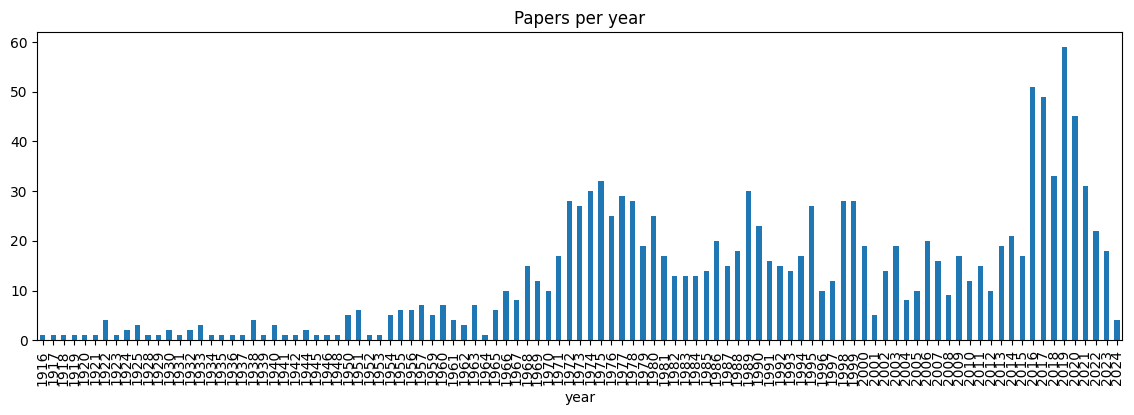

In [9]:
# Distribution of papers per year
df.groupby("year").size().plot(kind="bar", figsize=(14, 4), title="Papers per year")

In [10]:
# Which chapters have the most papers
pd.read_sql("""
    SELECT chapter_id, COUNT(*) as n
    FROM paper_chapters
    GROUP BY chapter_id
    ORDER BY n DESC
""", sqlite3.connect("black_holes.db"))

,chapter_id,n
0,evidence_sgr_a,205
1,precursor_quasars,178
2,evidence_agn_accretion,177
3,theory_hawking,145
4,evidence_eht,144
5,theory_foundation,137
6,evidence_cygnus_x1,134
7,evidence_gravitational_waves,129
8,precursor_xray_sky,112
9,precursor_redshift,44


# import images for the black hole story

In [12]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
fetch_black_hole_images.py — Source, verify, and download canonical images
for each black hole narrative chapter.

Strategy (two layers):
  1. Curated manifest — known images per chapter with their Wikimedia Commons
     filename or a manual-download note. These are the definitive visuals you
     want. The script verifies they exist and downloads them.
  2. Wikimedia Commons search — for each chapter, runs a keyword search to
     surface additional candidates you can eyeball in the notebook.

Output:
  images/                   — downloaded image files
  image_manifest.json       — per-chapter image metadata, paths, credits

Usage:
  python fetch_black_hole_images.py
  python fetch_black_hole_images.py --images-dir my_images --search-extras
"""

import argparse
import io
import json
import os
import sys
import time
import urllib.parse
import urllib.request
import urllib.error
from pathlib import Path
from typing import Dict, Any, List, Optional

if sys.stdout.encoding and sys.stdout.encoding.lower() != "utf-8":
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding="utf-8", errors="replace")

WIKIMEDIA_API = "https://commons.wikimedia.org/w/api.php"
WIKIMEDIA_THUMB = "https://commons.wikimedia.org/wiki/Special:FilePath/{filename}?width={width}"


In [13]:
# ---------------------------------------------------------------------------
# Curated image manifest
# ---------------------------------------------------------------------------
# Each entry has:
#   chapter_id    — matches fetch_black_holes.py chapter IDs
#   label         — short display label
#   source        — "wikimedia" | "manual"
#   filename      — Wikimedia Commons File: name (if source=="wikimedia")
#   manual_url    — landing page to visit for manual download (if source=="manual")
#   manual_file   — suggested local filename for manual downloads
#   credit        — attribution string to display
#   caption       — one-sentence display caption
#
# All Wikimedia filenames are the exact title after "File:" on Commons.
# ---------------------------------------------------------------------------
CURATED_IMAGES = [
    # -----------------------------------------------------------------------
    # precursor_stellar_theory
    # -----------------------------------------------------------------------
    {
        "chapter_id": "precursor_stellar_theory",
        "label": "Hertzsprung-Russell diagram",
        "source": "wikimedia",
        "filename": "HRDiagram.png",
        "credit": "Richard Powell / CC BY-SA 2.5",
        "caption": "The HR diagram showing stellar evolution paths — the context in which Chandrasekhar realised some stars could not stop collapsing.",
    },
    {
        "chapter_id": "precursor_stellar_theory",
        "label": "White dwarf comparison",
        "source": "wikimedia",
        "filename": "Sirius_A_and_B_Hubble_photo.jpg",
        "credit": "NASA, ESA / Public domain",
        "caption": "Sirius A and its white dwarf companion B — the type of object Chandrasekhar was calculating the mass limit for.",
    },

    # -----------------------------------------------------------------------
    # precursor_redshift
    # -----------------------------------------------------------------------
    {
        "chapter_id": "precursor_redshift",
        "label": "Pound-Rebka experiment",
        "source": "wikimedia",
        "filename": "Gravitational_red-shifting2.png",
        "credit": "Wikimedia Commons / CC BY-SA 3.0",
        "caption": "Diagram of the Pound-Rebka experiment (1959) — the first laboratory confirmation that gravity stretches light towards longer wavelengths.",
    },
    {
        "chapter_id": "precursor_redshift",
        "label": "Gravitational redshift spectrum",
        "source": "wikimedia",
        "filename": "Redshift.svg",
        "credit": "Georg Wiora / CC BY-SA 2.5",
        "caption": "Spectral lines shifted to longer wavelengths by a gravitational field — the observational signature that hinted at extreme gravity near compact objects.",
    },

    # -----------------------------------------------------------------------
    # precursor_quasars
    # -----------------------------------------------------------------------
    {
        "chapter_id": "precursor_quasars",
        "label": "3C 273 optical image",
        "source": "wikimedia",
        "filename": "3C273_quasar.jpg",
        "credit": "ESA/Hubble & NASA / Public domain",
        "caption": "3C 273, the first quasar to have its redshift measured (z=0.158, 1963) — a star-like point outshining entire galaxies.",
    },
    {
        "chapter_id": "precursor_quasars",
        "label": "Quasar jet (M87)",
        "source": "wikimedia",
        "filename": "M87_jet.jpg",
        "credit": "NASA and The Hubble Heritage Team (STScI/AURA) / Public domain",
        "caption": "The relativistic jet of M87, imaged by Hubble — visible evidence of the enormous energy output powered by a supermassive black hole.",
    },

    # -----------------------------------------------------------------------
    # precursor_xray_sky
    # -----------------------------------------------------------------------
    {
        "chapter_id": "precursor_xray_sky",
        "label": "Uhuru satellite",
        "source": "wikimedia",
        "filename": "Uhuru_satellite.jpg",
        "credit": "NASA / Public domain",
        "caption": "The Uhuru satellite (1970) — the first dedicated X-ray astronomy mission, which catalogued 339 X-ray sources including Cygnus X-1.",
    },
    {
        "chapter_id": "precursor_xray_sky",
        "label": "ROSAT all-sky X-ray map",
        "source": "wikimedia",
        "filename": "ROSAT_X-ray_map.gif",
        "credit": "Max Planck Institute for Extraterrestrial Physics / Public domain",
        "caption": "The entire X-ray sky as seen by ROSAT — the bright point sources that demanded compact-object explanations.",
    },

    # -----------------------------------------------------------------------
    # theory_foundation
    # -----------------------------------------------------------------------
    {
        "chapter_id": "theory_foundation",
        "label": "Penrose diagram of a black hole",
        "source": "wikimedia",
        "filename": "Penrose_diagram_of_black_hole.svg",
        "credit": "Wikimedia Commons / CC BY-SA 3.0",
        "caption": "A Penrose-Carter conformal diagram showing the causal structure of a black hole — once inside the event horizon, all future paths lead to the singularity.",
    },
    {
        "chapter_id": "theory_foundation",
        "label": "Schwarzschild geometry embedding",
        "source": "wikimedia",
        "filename": "Spacetime_curvature.png",
        "credit": "NASA / Public domain",
        "caption": "A spatial embedding diagram of the Schwarzschild geometry — the curved 'funnel' that represents spacetime near a non-rotating black hole.",
    },

    # -----------------------------------------------------------------------
    # theory_hawking
    # -----------------------------------------------------------------------
    {
        "chapter_id": "theory_hawking",
        "label": "Hawking radiation diagram",
        "source": "wikimedia",
        "filename": "Hawkingradiation.svg",
        "credit": "Wikimedia Commons / CC BY-SA 3.0",
        "caption": "Particle-antiparticle pairs created near the event horizon — one falls in, one escapes, causing the black hole to slowly evaporate.",
    },
    {
        "chapter_id": "theory_hawking",
        "label": "Stephen Hawking",
        "source": "wikimedia",
        "filename": "Stephen_Hawking.StarChild.jpg",
        "credit": "NASA / Public domain",
        "caption": "Stephen Hawking, whose 1974 paper predicting black hole thermal radiation was one of the most surprising results in theoretical physics.",
    },

    # -----------------------------------------------------------------------
    # evidence_cygnus_x1
    # -----------------------------------------------------------------------
    {
        "chapter_id": "evidence_cygnus_x1",
        "label": "Cygnus X-1 Chandra X-ray image",
        "source": "wikimedia",
        "filename": "Cygnus_X-1.png",
        "credit": "NASA/CXC/M.Weiss / Public domain",
        "caption": "Cygnus X-1 imaged in X-rays by Chandra — the first strong black hole candidate, established through its mass exceeding any possible neutron star.",
    },
    {
        "chapter_id": "evidence_cygnus_x1",
        "label": "Cygnus X-1 system diagram",
        "source": "wikimedia",
        "filename": "Cygnus_X-1_diagram.jpg",
        "credit": "NASA/CXC/M.Weiss / Public domain",
        "caption": "Artist's diagram of the Cygnus X-1 binary system — matter stripped from the blue supergiant HDE 226868 spirals into the black hole, emitting X-rays.",
    },

    # -----------------------------------------------------------------------
    # evidence_sgr_a
    # -----------------------------------------------------------------------
    {
        "chapter_id": "evidence_sgr_a",
        "label": "S2 stellar orbit around Sgr A*",
        "source": "wikimedia",
        "filename": "Galactic_centre_orbits.svg",
        "credit": "Wikimedia Commons / CC BY-SA 4.0",
        "caption": "Orbits of stars near Sagittarius A* mapped over 20 years — the tight ellipses require a four-million solar mass object in a region smaller than our solar system.",
    },
    {
        "chapter_id": "evidence_sgr_a",
        "label": "EHT image of Sgr A*",
        "source": "manual",
        "manual_url": "https://eventhorizontelescope.org/press-release-april-12-2022-astronomers-reveal-first-image-black-hole-heart-our-galaxy",
        "manual_file": "sgr_a_eht_2022.jpg",
        "credit": "EHT Collaboration / CC BY 4.0",
        "caption": "The first direct image of Sgr A*, the black hole at the centre of the Milky Way, released by the Event Horizon Telescope in 2022.",
    },

    # -----------------------------------------------------------------------
    # evidence_agn_accretion
    # -----------------------------------------------------------------------
    {
        "chapter_id": "evidence_agn_accretion",
        "label": "M87 jet (wide field)",
        "source": "wikimedia",
        "filename": "Messier_87_Hubble_WikiSky.jpg",
        "credit": "NASA, ESA, and the Hubble Heritage Team / Public domain",
        "caption": "Galaxy M87 with its famous jet — the visible output of a 6.5-billion solar mass black hole whose shadow was later imaged directly.",
    },
    {
        "chapter_id": "evidence_agn_accretion",
        "label": "Accretion disk artist impression",
        "source": "wikimedia",
        "filename": "Black_hole_accretion_disk.jpg",
        "credit": "NASA/JPL-Caltech / Public domain",
        "caption": "Artist's impression of an accretion disk — matter spiralling into a black hole heats up and emits X-rays, powering AGN across the universe.",
    },

    # -----------------------------------------------------------------------
    # evidence_gravitational_waves
    # -----------------------------------------------------------------------
    {
        "chapter_id": "evidence_gravitational_waves",
        "label": "GW150914 detection waveform",
        "source": "wikimedia",
        "filename": "LIGO_measurement_of_gravitational_waves.svg",
        "credit": "Caltech/MIT/LIGO Lab / CC BY 3.0",
        "caption": "The gravitational wave signal GW150914 detected simultaneously at LIGO Hanford and Livingston on 14 September 2015 — the chirp of two black holes merging.",
    },
    {
        "chapter_id": "evidence_gravitational_waves",
        "label": "LIGO aerial photograph",
        "source": "wikimedia",
        "filename": "LIGO_Hanford_aerial_05.jpg",
        "credit": "Caltech/MIT/LIGO Lab / CC BY-SA 3.0",
        "caption": "LIGO Hanford — one of the two L-shaped interferometers whose 4 km arms can detect a length change 10,000 times smaller than a proton.",
    },

    # -----------------------------------------------------------------------
    # evidence_eht
    # -----------------------------------------------------------------------
    {
        "chapter_id": "evidence_eht",
        "label": "M87* first image",
        "source": "wikimedia",
        "filename": "Black_hole_-_Messier_87_crop_max_res.jpg",
        "credit": "EHT Collaboration / CC BY 4.0",
        "caption": "The first direct image of a black hole shadow — M87*, released 10 April 2019. The bright ring is photons bent around a 6.5-billion solar mass object.",
    },
    {
        "chapter_id": "evidence_eht",
        "label": "Event Horizon Telescope array map",
        "source": "wikimedia",
        "filename": "EHT_2017_Locations.png",
        "credit": "EHT Collaboration / CC BY 4.0",
        "caption": "The eight observatories that formed the Earth-spanning EHT array in 2017 — together they constitute a virtual dish the diameter of Earth.",
    },
]


# ---------------------------------------------------------------------------
# Wikimedia Commons API helpers
# ---------------------------------------------------------------------------
def wm_api(params: Dict[str, Any]) -> Dict[str, Any]:
    params.setdefault("format", "json")
    qs = urllib.parse.urlencode(params, doseq=True)
    url = f"{WIKIMEDIA_API}?{qs}"
    for attempt in range(1, 5):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "mapo-image-fetcher/1.0"})
            with urllib.request.urlopen(req, timeout=30) as resp:
                return json.loads(resp.read().decode("utf-8"))
        except urllib.error.HTTPError as e:
            if e.code in (429, 503) and attempt < 4:
                time.sleep(2 * attempt)
                continue
            raise
        except urllib.error.URLError as e:
            if attempt < 4:
                time.sleep(2 * attempt)
                continue
            raise
    return {}


def resolve_wikimedia_url(filename: str, width: int = 1200) -> Optional[str]:
    """Return a direct image URL for a Wikimedia Commons filename."""
    data = wm_api({
        "action": "query",
        "titles": f"File:{filename}",
        "prop": "imageinfo",
        "iiprop": "url|size|mime",
        "iiurlwidth": width,
    })
    pages = (data.get("query") or {}).get("pages") or {}
    for page in pages.values():
        ii = (page.get("imageinfo") or [{}])[0]
        return ii.get("thumburl") or ii.get("url")
    return None


def search_wikimedia(query: str, limit: int = 5) -> List[Dict]:
    """Search Wikimedia Commons for images matching a query."""
    data = wm_api({
        "action": "query",
        "list": "search",
        "srsearch": f"{query} filetype:bitmap|drawing",
        "srnamespace": 6,
        "srlimit": limit,
        "srprop": "snippet|titlesnippet",
    })
    results = []
    for item in (data.get("query") or {}).get("search") or []:
        title = item.get("title", "")
        filename = title.replace("File:", "").strip()
        results.append({
            "filename": filename,
            "snippet": item.get("snippet", "").replace('<span class="searchmatch">', "").replace("</span>", ""),
        })
    return results


def download_file(url: str, dest: Path) -> bool:
    """Download url to dest. Returns True on success."""
    if dest.exists():
        print(f"    already exists: {dest.name}", flush=True)
        return True
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "mapo-image-fetcher/1.0"})
        with urllib.request.urlopen(req, timeout=60) as resp:
            data = resp.read()
        dest.write_bytes(data)
        print(f"    downloaded: {dest.name} ({len(data)//1024} KB)", flush=True)
        return True
    except Exception as e:
        print(f"    [error] could not download {url}: {e}", flush=True)
        return False


# ---------------------------------------------------------------------------
# Main logic
# ---------------------------------------------------------------------------
def process_curated(images_dir: Path) -> List[Dict]:
    """Resolve and download all curated images. Returns enriched manifest entries."""
    manifest = []

    for entry in CURATED_IMAGES:
        result = dict(entry)
        result["local_path"] = None
        result["resolved_url"] = None

        if entry["source"] == "wikimedia":
            filename = entry["filename"]
            print(f"  [{entry['chapter_id']}] {entry['label']}", flush=True)

            url = resolve_wikimedia_url(filename)
            if not url:
                print(f"    [warn] could not resolve {filename} on Wikimedia", flush=True)
                result["status"] = "unresolved"
            else:
                result["resolved_url"] = url
                ext = Path(filename).suffix or ".jpg"
                safe_name = filename.replace(" ", "_")
                dest = images_dir / safe_name
                ok = download_file(url, dest)
                result["local_path"] = str(dest) if ok else None
                result["status"] = "ok" if ok else "download_failed"

        elif entry["source"] == "manual":
            print(f"  [{entry['chapter_id']}] {entry['label']} — MANUAL DOWNLOAD REQUIRED", flush=True)
            print(f"    Visit: {entry['manual_url']}", flush=True)
            print(f"    Save as: images/{entry['manual_file']}", flush=True)
            dest = images_dir / entry["manual_file"]
            result["local_path"] = str(dest) if dest.exists() else None
            result["status"] = "present" if dest.exists() else "manual_required"

        time.sleep(0.3)
        manifest.append(result)

    return manifest


def run_extra_searches(images_dir: Path) -> Dict[str, List[Dict]]:
    """
    Run Wikimedia searches for each chapter to surface candidates beyond the
    curated set. Returns a dict keyed by chapter_id.
    """
    CHAPTER_SEARCHES = {
        "precursor_stellar_theory": "neutron star stellar collapse astronomy",
        "precursor_redshift": "gravitational redshift spectrum observation",
        "precursor_quasars": "quasar optical spectrum redshift",
        "precursor_xray_sky": "X-ray astronomy satellite telescope",
        "theory_foundation": "black hole event horizon diagram",
        "theory_hawking": "Hawking radiation quantum black hole",
        "evidence_cygnus_x1": "Cygnus X-1 X-ray binary",
        "evidence_sgr_a": "galactic centre infrared stars orbit",
        "evidence_agn_accretion": "active galaxy nucleus accretion disk jet",
        "evidence_gravitational_waves": "gravitational wave LIGO interferometer",
        "evidence_eht": "Event Horizon Telescope M87 shadow",
    }

    extras: Dict[str, List[Dict]] = {}
    for chapter_id, query in CHAPTER_SEARCHES.items():
        print(f"  searching: {chapter_id} ({query!r})", flush=True)
        results = search_wikimedia(query, limit=8)
        for r in results:
            url = resolve_wikimedia_url(r["filename"], width=800)
            r["thumb_url"] = url
        extras[chapter_id] = results
        time.sleep(0.4)

    return extras


def build_output(manifest: List[Dict], extras: Dict[str, List[Dict]], chapters_order: List[str]) -> Dict:
    by_chapter: Dict[str, List[Dict]] = {}
    for entry in manifest:
        cid = entry["chapter_id"]
        by_chapter.setdefault(cid, []).append(entry)

    output = {"chapters": []}
    for cid in chapters_order:
        output["chapters"].append({
            "chapter_id": cid,
            "curated_images": by_chapter.get(cid, []),
            "search_candidates": extras.get(cid, []),
        })
    return output


def print_summary(manifest: List[Dict]):
    ok = sum(1 for e in manifest if e.get("status") == "ok")
    manual = sum(1 for e in manifest if e.get("status") == "manual_required")
    present = sum(1 for e in manifest if e.get("status") == "present")
    failed = sum(1 for e in manifest if e.get("status") in ("unresolved", "download_failed"))

    print(f"\n{'='*60}")
    print(f"  Curated images: {len(manifest)} total")
    print(f"    Downloaded:       {ok}")
    print(f"    Already present:  {present}")
    print(f"    Manual required:  {manual}")
    print(f"    Failed/missing:   {failed}")
    print(f"{'='*60}")

    if manual > 0:
        print("\n  Images requiring manual download:")
        for e in manifest:
            if e.get("status") == "manual_required":
                print(f"    [{e['chapter_id']}] {e['label']}")
                print(f"      → {e.get('manual_url')}")
                print(f"      save as: images/{e.get('manual_file')}")


# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

In [14]:
p = argparse.ArgumentParser(description="Source and download images for black hole narrative chapters.")
p.add_argument("--images-dir", default="images", help="Directory to save images (default: images/)")
p.add_argument("--json-out", default="image_manifest.json", help="Output manifest path")
p.add_argument("--search-extras", action="store_true",
               help="Also run Wikimedia searches for extra candidates per chapter")
p.add_argument("--dry-run", action="store_true",
               help="Resolve URLs and print plan without downloading")
args = p.parse_args()

images_dir = Path(args.images_dir)
if not args.dry_run:
    images_dir.mkdir(exist_ok=True)

CHAPTER_ORDER = [e["id"] for e in [
    {"id": "precursor_stellar_theory"},
    {"id": "precursor_redshift"},
    {"id": "precursor_quasars"},
    {"id": "precursor_xray_sky"},
    {"id": "theory_foundation"},
    {"id": "theory_hawking"},
    {"id": "evidence_cygnus_x1"},
    {"id": "evidence_sgr_a"},
    {"id": "evidence_agn_accretion"},
    {"id": "evidence_gravitational_waves"},
    {"id": "evidence_eht"},
]]

print("\n=== Curated images ===", flush=True)
if args.dry_run:
    for entry in CURATED_IMAGES:
        src = entry.get("filename") or entry.get("manual_file")
        print(f"  [{entry['chapter_id']}] {entry['label']} — {src}")
    manifest = []
else:
    manifest = process_curated(images_dir)
    print_summary(manifest)

extras: Dict[str, List[Dict]] = {}
if args.search_extras and not args.dry_run:
    print("\n=== Wikimedia search candidates ===", flush=True)
    extras = run_extra_searches(images_dir)

output = build_output(manifest, extras, CHAPTER_ORDER)
with open(args.json_out, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)
print(f"\n[export] image_manifest.json written with {len(manifest)} curated entries")

usage: ipykernel_launcher.py [-h] [--images-dir IMAGES_DIR] [--json-out JSON_OUT] [--search-extras] [--dry-run]
ipykernel_launcher.py: error: unrecognized arguments: -f C:\Users\TomHi\AppData\Roaming\jupyter\runtime\kernel-8fca8452-fbcb-4244-a7bf-104aeff012b1.json


SystemExit: 2

C:\Users\TomHi\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
